In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", DEVICE)

DATA_PATH = "S12-hw-dataset.csv"
ARTIFACTS_DIR = "artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")
CSV_PATH = os.path.join(ARTIFACTS_DIR, "runs.csv")

os.makedirs(FIGURES_DIR, exist_ok=True)

Устройство: cpu


In [30]:
df = pd.read_csv(DATA_PATH)

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


Размер: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00

Пропуски:
 date      0
target    0
dtype: int64


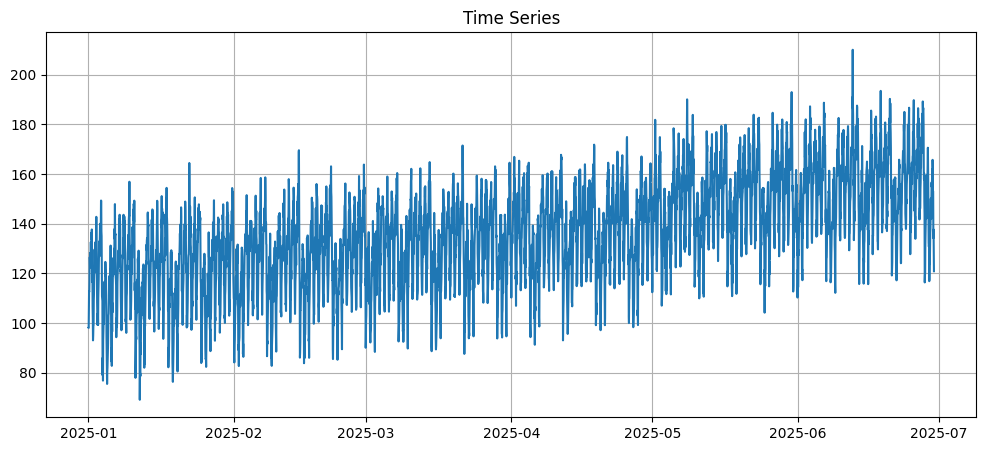

In [ ]:
print("Размер:", df.shape)
print("Диапазон дат:", df['date'].min(), "—", df['date'].max())
print("\nПропуски:\n", df.isna().sum())

plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['target'])
plt.title("Time Series")
plt.grid()
plt.show()

Тренд - это долгосрочное направление изменения ряда. В данном ряду видно, что тренд растет со временем

Сезонность - это повторяющиеся паттерны через фиксированные промежутки времени. В данных заметна выраженная внутрисуточная сезонность: значения регулярно растут в дневные часы и снижаются ночью

В ряду можно заметить отдельные резкие падения (скорее всего из-за сезонности?). Скорее всего они являются частью нормальной вариативности

Нестационарность - это изменение статистических свойств ряда со временем. Ряд можно считать частично нестационарным: средний уровень немного растет, присутствует сезонность

3024 648 648


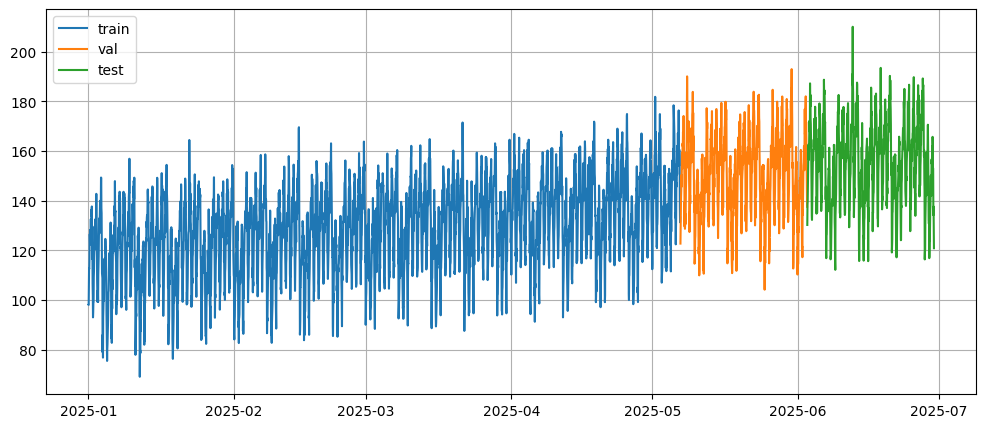

In [3]:
n = len(df)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print(len(train_df), len(val_df), len(test_df))

plt.figure(figsize=(12, 5))
plt.plot(train_df['date'], train_df['target'], label='train')
plt.plot(val_df['date'], val_df['target'], label='val')
plt.plot(test_df['date'], test_df['target'], label='test')
plt.legend()
plt.grid()

plt.savefig(os.path.join(FIGURES_DIR, "series_split.png"))
plt.show()

random split для этой задачи некорректен, так как в выборку могут попадать значения из будущего, что повлияет на качество обучения модели (в реальности она эти данные узнать никак не сможет)

In [4]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    eps = 1e-8
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mape = np.mean(np.abs((y_true - y_pred) / y_true + eps)) * 100
    return int(round(mae, 2)), int(round(rmse, 2)), int(round(mape, 2))

In [5]:
def create_features(df):
    df = df.copy()
    
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)

    df['rolling_mean_7'] = df['target'].rolling(7).mean()
    df['rolling_std_7'] = df['target'].rolling(7).std()

    df['day_of_week'] = df['date'].dt.dayofweek

    return df

df_feat = create_features(df)
df_feat = df_feat.dropna().reset_index(drop=True)

In [6]:
def save_experiment_result(filepath, **kwargs):
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    
    fields = [
        "experiment_id", "task", "dataset", "seed", "split_summary", "window_size", "horizon", "model_summary", 
        "features_summary", "scaler", "optimizer", "lr", "epochs_trained", "best_val_mae", "best_val_rmse", 
        "best_val_mape", "test_mae", "test_rmse", "test_mape", "notes"
    ]
    
    file_exists = os.path.isfile(filepath)
    
    with open(filepath, 'a', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fields, extrasaction='ignore')
        if not file_exists:
            writer.writeheader()
        writer.writerow({field: kwargs.get(field, '') for field in fields})

**B1 (`naive-last`)**: наивный baseline, где прогноз равен последнему известному значению

In [7]:
def naive_last(train, val):
    preds = val['target'].shift(1)
    preds.iloc[0] = train['target'].iloc[-1]
    return preds.values

val_pred_b1 = naive_last(train_df, val_df)
B1_mae, B1_rmse, B1_mape = compute_metrics(val_df['target'], val_pred_b1)

print("B1:", B1_mae, B1_rmse, B1_mape)

B1: 6 8 4


C:\Users\vlada\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
save_experiment_result(CSV_PATH,
    experiment_id="B1",
    task="forecasting",
    dataset=DATA_PATH,
    seed=SEED,
    split_summary="temporal:train[0:70%]/val[70:85%]/test[85:100%]",
    window_size=1,
    horizon=1,
    model_summary="naive-last (y_t = y_{t-1})",
    features_summary="target(t-1)",
    scaler="none",
    optimizer="none",
    lr="",
    epochs_trained=0,
    best_val_mae=B1_mae,
    best_val_rmse=B1_rmse, 
    best_val_mape=B1_mape, 
    test_mae="",
    test_rmse="",
    test_mape="",
    notes=""
)

**B2 (`moving-average`)**: baseline на основе скользящего среднего по окну разумного размера

In [9]:
def moving_average(series, window=7):
    return series.rolling(window).mean()

val_pred_b2 = moving_average(pd.concat([train_df, val_df])['target'], 7).iloc[-len(val_df):].values

B2_mae, B2_rmse, B2_mape = compute_metrics(val_df['target'], val_pred_b2)

print("B2:", B2_mae, B2_rmse, B2_mape)

B2: 10 12 6


C:\Users\vlada\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
save_experiment_result(CSV_PATH,
    experiment_id="B2",
    task="forecasting",
    dataset=DATA_PATH,
    seed=SEED,
    split_summary="temporal:train[0:70%]/val[70:85%]/test[85:100%]",
    window_size=7,
    horizon=1,
    model_summary="moving-average (window=7)",
    features_summary="rolling_mean_7",
    scaler="none",
    optimizer="none",
    lr="",
    epochs_trained=0,
    best_val_mae=B2_mae,
    best_val_rmse=B2_rmse, 
    best_val_mape=B2_mape, 
    test_mae="",
    test_rmse="",
    test_mape="",
    notes=""
)

**B3 (`ridge-lag-features`)**: `Ridge` (или `LinearRegression`) на лаговых, rolling- и календарных признаках

In [11]:
features = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week']

train_feat = df_feat.iloc[:train_end].dropna()
val_feat = df_feat.iloc[train_end:val_end].dropna()

model = Ridge()
model.fit(train_feat[features], train_feat['target'])

val_pred_b3 = model.predict(val_feat[features])

B3_mae, B3_rmse, B3_mape = compute_metrics(val_feat['target'], val_pred_b3)
print("B3:", B3_mae, B3_rmse, B3_mape)

B3: 6 8 4


C:\Users\vlada\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
save_experiment_result(CSV_PATH,
    experiment_id="B3",
    task="forecasting",
    dataset=DATA_PATH,
    seed=SEED,
    split_summary="temporal:train[0:70%]/val[70:85%]/test[85:100%]",
    window_size=14,
    horizon=1,
    model_summary="Ridge(alpha=1.0)",
    features_summary="lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, day_of_week",
    scaler="none",
    optimizer="",
    lr="",
    epochs_trained=1,
    best_val_mae=B3_mae,
    best_val_rmse=B3_rmse, 
    best_val_mape=B3_mape, 
    test_mae="",
    test_rmse="",
    test_mape="",
    notes=""
)

**R1 (`gru-forecast`)**: `GRU` на оконном представлении ряда

In [13]:
class TimeSeriesDataset(Dataset):
    def __init__(self, series, window):
        self.series = series
        self.window = window

    def __len__(self):
        return len(self.series) - self.window

    def __getitem__(self, idx):
        x = self.series[idx:idx+self.window]
        y = self.series[idx+self.window]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)
    
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.unsqueeze(-1)
        out, _ = self.gru(x)
        out = self.fc(out[:, -1])
        return out.squeeze()

In [ ]:
window_size = 28  # Глубина контекста: модель смотрит на 28 дней в прошлое

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)


def make_windows(series_2d: np.ndarray, window_size: int):
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size]) 
        y.append(series_2d[i + window_size, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)


X_train: (2996, 28, 1) y_train: (2996,)
X_val  : (620, 28, 1) y_val  : (620,)
X_test : (620, 28, 1) y_test : (620,)


Форма одного окна: (28, 1)
Первые 5 значений окна: [-1.6267993  -1.6305869  -1.2718506  -0.8330344  -0.84331495]
Цель: -0.8963408


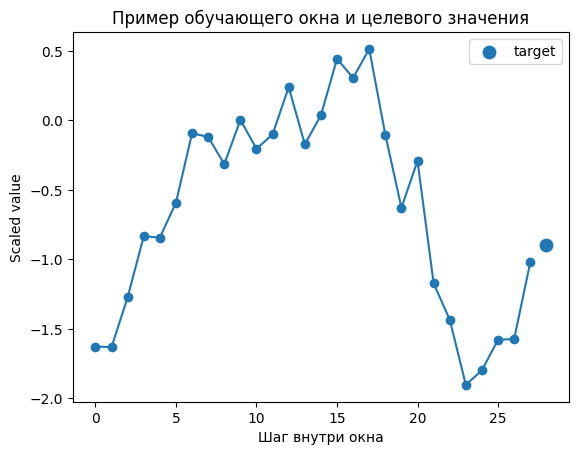

In [15]:
sample_idx = 0

print("Форма одного окна:", X_train[sample_idx].shape)
print("Первые 5 значений окна:", X_train[sample_idx][:5].ravel())
print("Цель:", y_train[sample_idx])

fig, ax = plt.subplots()
ax.plot(np.arange(window_size), X_train[sample_idx].ravel(), marker="o")
ax.scatter([window_size], [y_train[sample_idx]], s=80, label="target")
ax.set_title("Пример обучающего окна и целевого значения")
ax.set_xlabel("Шаг внутри окна")
ax.set_ylabel("Scaled value")
ax.legend()
plt.show()

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (num_samples, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (num_samples,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64  # Размер батча для градиентного спуска

train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  # (batch_size, window_size, 1)
print("Batch y:", yb.shape)  # (batch_size,)

Batch X: torch.Size([64, 28, 1])
Batch y: torch.Size([64])


In [17]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

In [18]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=DEVICE):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) 

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss
            torch.save(model.state_dict(), os.path.join(ARTIFACTS_DIR, "best_gru.pt"))

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history


In [19]:
set_seed(42)
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(DEVICE)
print("GRU params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=DEVICE)

GRU params: 37889
Epoch 01 | train_loss=0.6994 | val_loss=0.6024
Epoch 02 | train_loss=0.2726 | val_loss=0.3549
Epoch 03 | train_loss=0.1632 | val_loss=0.2236
Epoch 04 | train_loss=0.1544 | val_loss=0.1980
Epoch 05 | train_loss=0.1512 | val_loss=0.1802
Epoch 06 | train_loss=0.1503 | val_loss=0.2615
Epoch 07 | train_loss=0.1463 | val_loss=0.2079
Epoch 08 | train_loss=0.1483 | val_loss=0.1745
Epoch 09 | train_loss=0.1463 | val_loss=0.3428
Epoch 10 | train_loss=0.1450 | val_loss=0.1793
Epoch 11 | train_loss=0.1419 | val_loss=0.2051
Epoch 12 | train_loss=0.1410 | val_loss=0.2272
Epoch 13 | train_loss=0.1373 | val_loss=0.2138
Epoch 14 | train_loss=0.1347 | val_loss=0.2043
Epoch 15 | train_loss=0.1305 | val_loss=0.2379
Epoch 16 | train_loss=0.1248 | val_loss=0.2244
Epoch 17 | train_loss=0.1172 | val_loss=0.1987
Epoch 18 | train_loss=0.1112 | val_loss=0.2192
Epoch 19 | train_loss=0.1129 | val_loss=0.1705
Epoch 20 | train_loss=0.1042 | val_loss=0.1719
Epoch 21 | train_loss=0.1053 | val_loss=0.

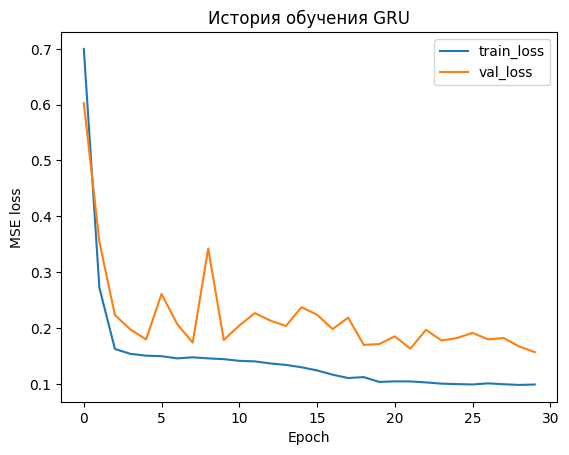

In [20]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.savefig(os.path.join(FIGURES_DIR, "gru_learning_curves.png"))
plt.show()

In [ ]:
@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()

gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, DEVICE)

gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)
gru_val_true = inverse_scale(gru_val_true_scaled, scaler)

R1_mae, R1_rmse, R1_mape = compute_metrics(gru_val_true, gru_val_pred)

val_metrics = pd.DataFrame([
    {"Experiment": "B1", "MAE": B1_mae, "MAPE": B1_mape, "RMSE": B1_rmse},
    {"Experiment": "B2", "MAE": B2_mae, "MAPE": B2_mape, "RMSE": B2_rmse},
    {"Experiment": "B3", "MAE": B3_mae, "MAPE": B3_mape, "RMSE": B3_rmse},
    {"Experiment": "R1", "MAE": R1_mae, "MAPE": R1_mape, "RMSE": R1_rmse},
]).sort_values("RMSE")


val_metrics


C:\Users\vlada\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,Experiment,MAE,MAPE,RMSE
3,R1,5,3,7
0,B1,6,4,8
2,B3,6,4,8
1,B2,10,6,12


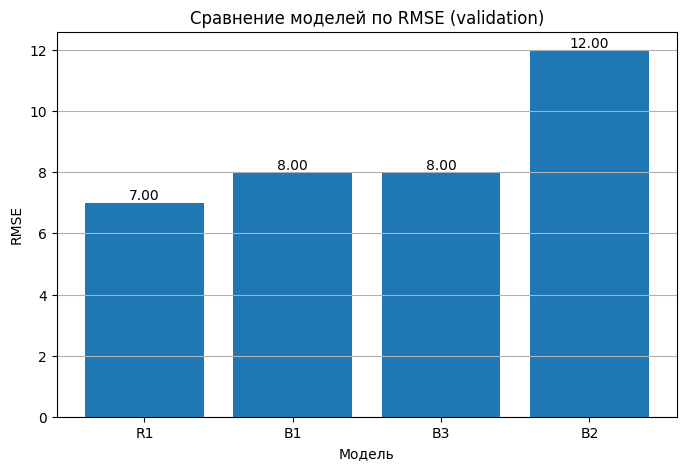

In [35]:
plt.figure(figsize=(8, 5))
plt.bar(val_metrics["Experiment"], val_metrics["RMSE"])
plt.title("Сравнение моделей по RMSE (validation)")
plt.xlabel("Модель")
plt.ylabel("RMSE")

for i, v in enumerate(val_metrics["RMSE"]):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.grid(axis='y')
plt.savefig(os.path.join(FIGURES_DIR, "baselines_compare.png"))
plt.show()

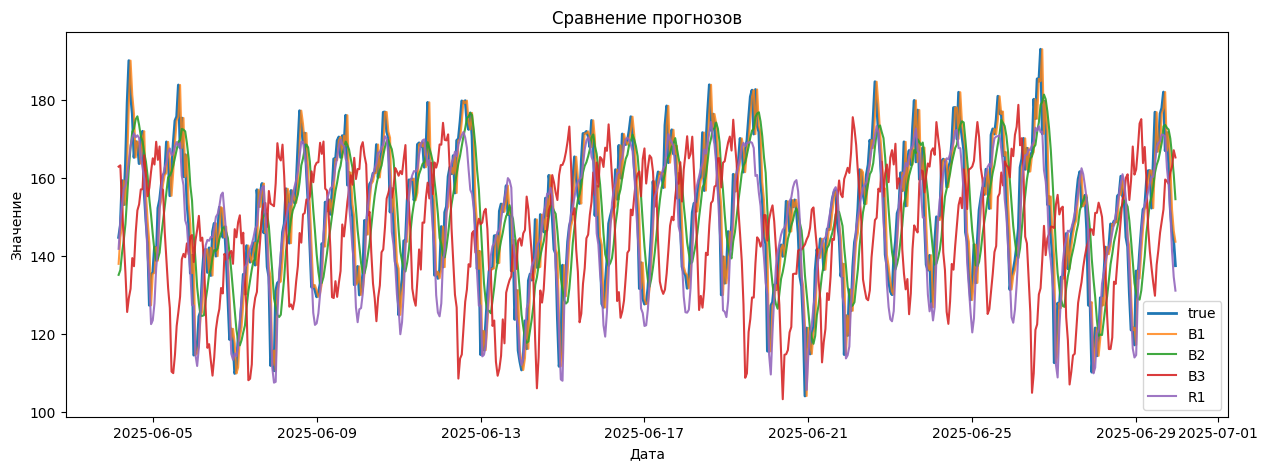

In [ ]:
offset = window_size

B1_aligned = val_pred_b1[offset:]
B2_aligned = val_pred_b2[offset:]
B3_aligned = val_pred_b3[offset:]

plot_df = pd.DataFrame(
    {
        "date": test_df["date"].iloc[window_size:].reset_index(drop=True),
        "true": gru_val_true,
        "B1": B1_aligned,
        "B2": B2_aligned,
        "B3": B3_aligned,
        "R1": gru_val_pred
    }
)


# Строим полные прогнозы всех трех подходов
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_df["date"], plot_df["true"], label="true", lw=2)
ax.plot(plot_df["date"], plot_df["B1"], label="B1", alpha=0.8)
ax.plot(plot_df["date"], plot_df["B2"], label="B2", alpha=0.9)
ax.plot(plot_df["date"], plot_df["B3"], label="B3", alpha=0.9)
ax.plot(plot_df["date"], plot_df["R1"], label="R1", alpha=0.9)
ax.set_title("Сравнение прогнозов")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.show()

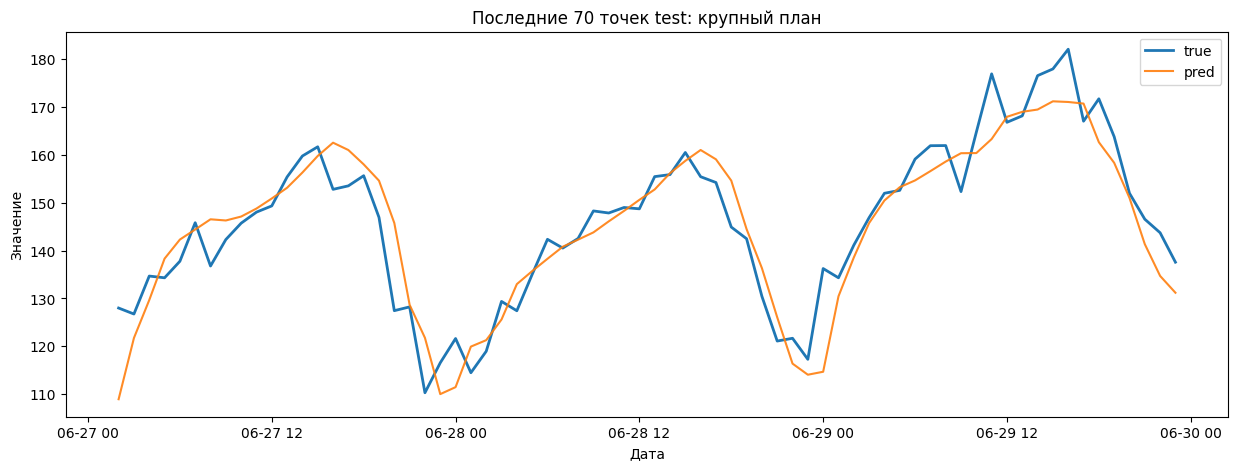

In [23]:
fig, ax = plt.subplots(figsize=(15, 5))
tail_df = plot_df.tail(70)
ax.plot(tail_df["date"], tail_df["true"], label="true", lw=2)
ax.plot(tail_df["date"], tail_df["R1"], label="pred", alpha=0.9)
ax.set_title("Последние 70 точек test: крупный план")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.savefig(os.path.join(FIGURES_DIR, "best_forecast_test.png"))

plt.show()

In [32]:
gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, DEVICE)
gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler)
gru_test_true = inverse_scale(gru_test_true_scaled, scaler)

R1_test_mae, R1_test_rmse, R1_test_mape = compute_metrics(gru_test_true, gru_test_pred)

print("Тестовые метрики", R1_test_mae, R1_test_rmse, R1_test_mape)

Тестовые метрики 6 8 4


C:\Users\vlada\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
save_experiment_result(CSV_PATH,
    experiment_id="R1",
    task="forecasting",
    dataset=DATA_PATH,
    seed=SEED,
    split_summary="temporal:train[0:70%]/val[70:85%]/test[85:100%]",
    window_size=window_size,
    horizon=1,
    model_summary="GRU(hidden_size=64, num_layers=1)",
    features_summary="raw target sequence",
    scaler="StandardScaler (на train)",
    optimizer="Adam",
    lr=1e-3,
    epochs_trained=len(gru_history['train_loss']),
    best_val_mae=R1_mae,
    best_val_rmse=R1_rmse, 
    best_val_mape=R1_mape, 
    test_mae=R1_test_mae,
    test_rmse=R1_test_rmse,
    test_mape=R1_test_mape,
    notes=""
)

In [ ]:
config = {
    "model": "GRU",
    "window_size": window_size,
    "hidden_size": 64,
    "batch_size": batch_size,
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs": len(gru_history["val_loss"]),
    "seed": SEED
}

with open(os.path.join(ARTIFACTS_DIR, "best_gru_config.json"), "w") as f:
    json.dump(config, f, indent=4)